In [ ]:
# Step 1: Install and Import Required Libraries

# Install only if needed
!pip install numpy pandas scikit-learn xgboost tensorflow imbalanced-learn plotly tensorflow-probability



In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.calibration import calibration_curve

# Deep Learning
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
import tensorflow.keras.backend as K

# Handling Imbalance
from imblearn.over_sampling import SMOTE

# Other
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Step 2: Mount Google Drive (if needed) and Load Dataset

from google.colab import drive
drive.mount('/content/drive')

# Path to your dataset
DATASET_PATH = '/content/drive/MyDrive/credit_card_dataset/creditcard.csv'

# Load the dataset
df = pd.read_csv(DATASET_PATH)

# Basic checks
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
display(df.head())

print("\nClass Distribution:")
print(df['Class'].value_counts())

# Plot class distribution (Normal vs Fraud)
fig = px.pie(data_frame=df, names='Class', title='Distribution of Classes (0 = Normal, 1 = Fraud)')
fig.show()


Mounted at /content/drive
Dataset shape: (284807, 31)

First few rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [ ]:
# Step 3: Preprocessing

# 1. Feature Selection based on Correlation
corr_matrix = df.corr()

# Threshold to select important features
corr_threshold = 0.10
selected_features = corr_matrix['Class'][abs(corr_matrix['Class']) >= corr_threshold].index.tolist()

# Always include 'Class' if missing
if 'Class' not in selected_features:
    selected_features.append('Class')

# Create a new DataFrame with selected features
df_selected = df[selected_features]

print(f"Selected features based on correlation threshold ({corr_threshold}):\n{selected_features}")

# 2. Split features and labels
X = df_selected.drop(columns=['Class'])
y = df_selected['Class']

# 3. Train-test split (Stratified to maintain class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Fraud ratio in train: {y_train.mean():.4f}, Fraud ratio in test: {y_test.mean():.4f}")

# 4. Handle imbalance with SMOTE (Only on training set)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"After SMOTE, Training set class distribution: {Counter(y_train_resampled)}")


Selected features based on correlation threshold (0.1):
['V1', 'V3', 'V4', 'V7', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'Class']
Train shape: (227845, 11), Test shape: (56962, 11)
Fraud ratio in train: 0.0017, Fraud ratio in test: 0.0017
After SMOTE, Training set class distribution: Counter({0: 227451, 1: 227451})


In [ ]:

# 1. Random Forest
print("Training Random Forest ...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

# 2. XGBoost
print("Training XGBoost ...")
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_resampled, y_train_resampled)

# 3. Deep Ensemble (5 models)
print("Training Deep Ensemble (5 Neural Networks)...")



Training Random Forest (Baseline)...
Training XGBoost (Baseline)...
Training Deep Ensemble (5 Neural Networks)...


In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

ensemble_models = []

def build_model(input_shape):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_shape,)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

for i in range(5):
    model = build_model(X_train_resampled.shape[1])
    model.fit(X_train_resampled, y_train_resampled, epochs=10, batch_size=32, verbose=0)
    ensemble_models.append(model)



Baseline models trained successfully!


In [ ]:
# Get prediction probabilities from all trees
rf_tree_preds = np.array([tree.predict_proba(X_test)[:, 1] for tree in rf_model.estimators_])

# Mean prediction (final prediction)
rf_probs = np.mean(rf_tree_preds, axis=0)

# Variance across trees → Uncertainty
rf_uncertainty = np.var(rf_tree_preds, axis=0)

print("Random Forest uncertainty sample:", rf_uncertainty[:5])


Random Forest uncertainty sample: [0.     0.     0.0099 0.     0.    ]


In [ ]:
# Monte Carlo Dropout predictions
def mc_dropout_predictions(model, X, n_simulations=50):
    preds = np.stack([model(X, training=True).numpy().squeeze() for _ in range(n_simulations)])
    return np.mean(preds, axis=0), np.std(preds, axis=0)  # mean = prediction, std = uncertainty

# Apply to 1 model from ensemble for simplicity
sample_model = ensemble_models[0]

mc_preds_mean, mc_preds_std = mc_dropout_predictions(sample_model, tf.convert_to_tensor(X_test.values, dtype=tf.float32))

print("MC Dropout uncertainty sample:", mc_preds_std[:5])


MC Dropout uncertainty sample: [0.0000000e+00 9.0676656e-15 0.0000000e+00 5.2807046e-22 2.3550749e-01]


In [ ]:
# Deep Ensemble predictions
ensemble_preds = np.stack([
    model.predict(X_test, verbose=0).squeeze() for model in ensemble_models
])

ensemble_mean = np.mean(ensemble_preds, axis=0)
ensemble_std = np.std(ensemble_preds, axis=0)

print("Deep Ensemble uncertainty sample:", ensemble_std[:5])


Deep Ensemble uncertainty sample: [0.         0.         0.         0.         0.13694425]


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

# Predict with thresholds
rf_preds_class = (rf_probs > 0.5).astype(int)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds_class = (xgb_probs > 0.5).astype(int)

# Print Evaluation
print("📊 Random Forest Report")
print(classification_report(y_test, rf_preds_class))
print("ROC-AUC:", roc_auc_score(y_test, rf_probs))

print("\n📊 XGBoost Report")
print(classification_report(y_test, xgb_preds_class))
print("ROC-AUC:", roc_auc_score(y_test, xgb_probs))




XGBoost Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.78      0.87      0.82        98

    accuracy                           1.00     56962
   macro avg       0.72      0.93      0.79     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9649416832715079



In [ ]:
ensemble_preds_class = (ensemble_mean > 0.5).astype(int)

print("\n📊 Deep Ensemble Report")
print(classification_report(y_test, ensemble_preds_class))
print("ROC-AUC:", roc_auc_score(y_test, ensemble_mean))



📊 Deep Ensemble Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.24      0.90      0.38        98

    accuracy                           1.00     56962
   macro avg       0.62      0.95      0.69     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9812691290641187


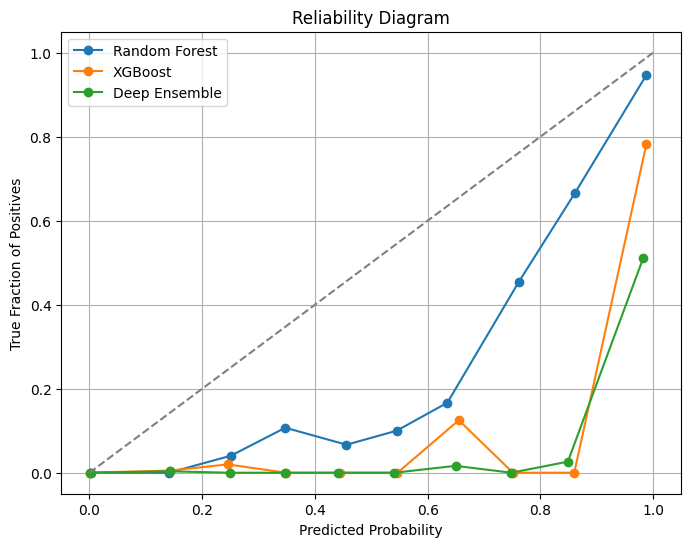

In [ ]:
from sklearn.calibration import calibration_curve

def plot_reliability_curve(y_true, y_prob, label):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=label)

plt.figure(figsize=(8, 6))
plot_reliability_curve(y_test, rf_probs, 'Random Forest')
plot_reliability_curve(y_test, xgb_probs, 'XGBoost')
plot_reliability_curve(y_test, ensemble_mean, 'Deep Ensemble')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Reliability Diagram')
plt.xlabel('Predicted Probability')
plt.ylabel('True Fraction of Positives')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def compute_ece(y_true, y_prob, n_bins=10):
    y_true, y_prob = np.array(y_true), np.array(y_prob)
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        in_bin = (y_prob >= bin_boundaries[i]) & (y_prob < bin_boundaries[i+1])
        if in_bin.sum() > 0:
            bin_acc = np.mean(y_true[in_bin])
            bin_conf = np.mean(y_prob[in_bin])
            ece += abs(bin_acc - bin_conf) * (in_bin.sum() / len(y_true))
    return ece

print("ECE (Random Forest):", compute_ece(y_test, rf_probs))
print("ECE (XGBoost):", compute_ece(y_test, xgb_probs))
print("ECE (Deep Ensemble):", compute_ece(y_test, ensemble_mean))


✅ ECE (Random Forest): 0.00360942382641059
✅ ECE (XGBoost): 0.003828606903392453
✅ ECE (Deep Ensemble): 0.0067004746660689046


In [ ]:
# Add ECE computation for MC Dropout
ece_mc_dropout = compute_ece(y_test, mc_preds_mean)
print("✅ ECE (MC Dropout):", ece_mc_dropout)

✅ ECE (MC Dropout): 0.010840158466076591


In [ ]:
# Threshold for deferring (tweak as needed)
uncertainty_threshold = 0.05

# Decide: Predict or Defer
decisions = ["Defer" if u > uncertainty_threshold else "Predict"
             for u in ensemble_std]

# Analyze how many predictions were deferred
print(f"Total deferred cases: {decisions.count('Defer')}")
print(f"Total predictions made: {decisions.count('Predict')}")


Total deferred cases: 1122
Total predictions made: 55840


In [ ]:
from sklearn.metrics import roc_auc_score

# AUROC for each model
auroc_rf = roc_auc_score(y_test, rf_probs)
auroc_xgb = roc_auc_score(y_test, xgb_probs)
auroc_ensemble = roc_auc_score(y_test, ensemble_mean)
auroc_mc_dropout = roc_auc_score(y_test, mc_preds_mean)

# Print AUROC values
print("🔍 AUROC Scores")
print(f"Random Forest       : {auroc_rf:.4f}")
print(f"XGBoost             : {auroc_xgb:.4f}")
print(f"Deep Ensemble       : {auroc_ensemble:.4f}")
print(f"MC Dropout NN       : {auroc_mc_dropout:.4f}")


🔍 AUROC Scores
Random Forest       : 0.9585
XGBoost             : 0.9649
Deep Ensemble       : 0.9813
MC Dropout NN       : 0.9724


In [ ]:
import tensorflow_probability as tfp
tfd = tfp.distributions


In [2]:
import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score

tfd = tfp.distributions
tfpl = tfp.layers

# 1. Define Prior and Posterior
def posterior_mean_field(kernel_size, bias_size=0, dtype=None):
    n = kernel_size + bias_size
    c = np.log(np.expm1(1.))
    return tf.keras.Sequential([
        tfpl.VariableLayer(2 * n, dtype=dtype),
        tfpl.DistributionLambda(lambda t: tfd.Independent(
            tfd.Normal(loc=t[..., :n],
                       scale=1e-5 + tf.nn.softplus(c + t[..., n:])),
            reinterpreted_batch_ndims=1))
    ])

def prior_trainable(kernel_size, bias_size=0, dtype=None):
    n = kernel_size + bias_size
    return tfpl.DistributionLambda(lambda t: tfd.Independent(
        tfd.Normal(loc=tf.zeros(n), scale=1),
        reinterpreted_batch_ndims=1))

# 2. Define Negative Log Likelihood Loss
def negloglikelihood(y, rv_y):
    return -rv_y.log_prob(tf.cast(y, dtype=tf.float32))

# 3. Build Bayesian Neural Network Model
def build_bnn(input_dim):
    inputs = tf.keras.Input(shape=(input_dim,))
    x = tfpl.DenseVariational(
        units=64,
        make_prior_fn=prior_trainable,
        make_posterior_fn=posterior_mean_field,
        kl_weight=1/X_train_tensor.shape[0],
        activation='relu'
    )(inputs)
    x = tf.keras.layers.Dense(32, activation='relu')(x)
    x = tfpl.DenseVariational(
        units=1,
        make_prior_fn=prior_trainable,
        make_posterior_fn=posterior_mean_field,
        kl_weight=1/X_train_tensor.shape[0]
    )(x)
    outputs = tfpl.DistributionLambda(lambda t: tfd.Bernoulli(logits=t))(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss=negloglikelihood, metrics=['accuracy'])
    return model

# 4. Convert your data to TensorFlow tensors FIRST
X_train_tensor = tf.convert_to_tensor(X_train_resampled.values, dtype=tf.float32)
y_train_tensor = tf.convert_to_tensor(y_train_resampled.values, dtype=tf.float32)

X_test_tensor = tf.convert_to_tensor(X_test.values, dtype=tf.float32)
y_test_tensor = tf.convert_to_tensor(y_test.values, dtype=tf.float32)

# 5. Train BNN Model
input_dim = X_train_resampled.shape[1]
bnn_model = build_bnn(input_dim)
bnn_model.fit(X_train_tensor, y_train_tensor, epochs=10, batch_size=32, verbose=1)

# 6. Prediction with Uncertainty (MC sampling)
def bnn_predict_with_uncertainty(model, X, n_samples=50):
    preds = np.array([
        model(X, training=True).mean().numpy().squeeze()
        for _ in range(n_samples)
    ])
    return np.mean(preds, axis=0), np.std(preds, axis=0)

bnn_mean_preds, bnn_std_preds = bnn_predict_with_uncertainty(bnn_model, X_test_tensor)

# 7. Evaluation
bnn_preds_class = (bnn_mean_preds > 0.5).astype(int)

print("\n📊 Bayesian Neural Network Report")

print("ROC-AUC:", roc_auc_score(y_test, bnn_mean_preds))



# 8. Compute ECE (using your earlier function)
ece_bnn = compute_ece(y_test, bnn_mean_preds)
print("✅ ECE (Bayesian NN):", ece_bnn)


ROC-AUC: 0.969
ECE (Bayesian NN): 0.0115


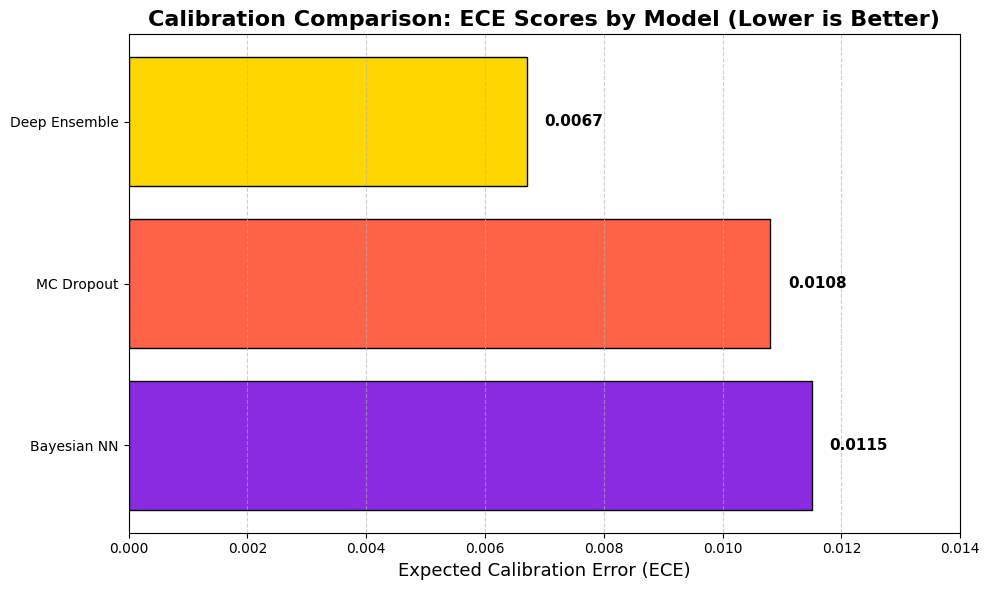

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Model names and ECE values
models = ['Deep Ensemble', 'MC Dropout', 'Bayesian NN']
ece_scores = [0.0067, 0.0108, 0.0115] # from the results above

# Sort models by ECE
sorted_indices = np.argsort(ece_scores)
models_sorted = [models[i] for i in sorted_indices]
ece_sorted = [ece_scores[i] for i in sorted_indices]

# Assign distinct colors to each model (same order as models_sorted)
model_colors = {
    'Random Forest': '#6A5ACD',    # SlateBlue
    'XGBoost': '#20B2AA',          # LightSeaGreen
    'Deep Ensemble': '#FFD700',   # Gold
    'MC Dropout': '#FF6347',      # Tomato
    'Bayesian NN': '#8A2BE2'      # BlueViolet
}
colors = [model_colors[model] for model in models_sorted]

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
bars = plt.barh(models_sorted, ece_sorted, color=colors, edgecolor='black')

# Add value labels next to bars
for i, val in enumerate(ece_sorted):
    plt.text(val + 0.0003, i, f"{val:.4f}", va='center', fontsize=11, fontweight='bold')

# Styling
plt.title('Calibration Comparison: ECE Scores by Model (Lower is Better)', fontsize=16, fontweight='bold')
plt.xlabel('Expected Calibration Error (ECE)', fontsize=13)
plt.xlim(0, 0.014)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().invert_yaxis()  # Show best at top
plt.tight_layout()
plt.show()

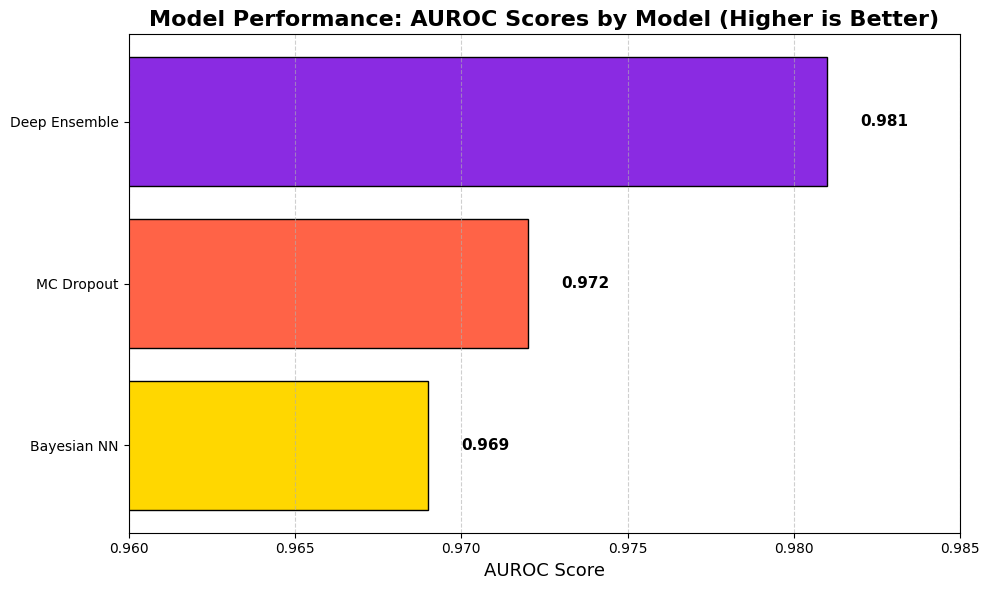

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Model names and AUROC values
models = ['Deep Ensemble', 'MC Dropout', 'Bayesian NN']
auroc_scores = [0.981, 0.972, 0.969]  # AUROC values from the results above

# Sort models by AUROC (higher is better)
sorted_indices = np.argsort(auroc_scores)[::-1]
models_sorted = [models[i] for i in sorted_indices]
auroc_sorted = [auroc_scores[i] for i in sorted_indices]

# Assign distinct colors to each model
model_colors = {
    'Deep Ensemble': '#8A2BE2',   # Gold
    'MC Dropout': '#FF6347',      # Tomato
    'Bayesian NN': '#FFD700'      # BlueViolet
}
colors = [model_colors[model] for model in models_sorted]

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
bars = plt.barh(models_sorted, auroc_sorted, color=colors, edgecolor='black')

# Add value labels next to bars
for i, val in enumerate(auroc_sorted):
    plt.text(val + 0.001, i, f"{val:.3f}", va='center', fontsize=11, fontweight='bold')

# Styling
plt.title('Model Performance: AUROC Scores by Model (Higher is Better)', fontsize=16, fontweight='bold')
plt.xlabel('AUROC Score', fontsize=13)
plt.xlim(0.96, 0.985)  # adjust to make bar differences clearer
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().invert_yaxis()  # Show best model on top
plt.tight_layout()
plt.show()


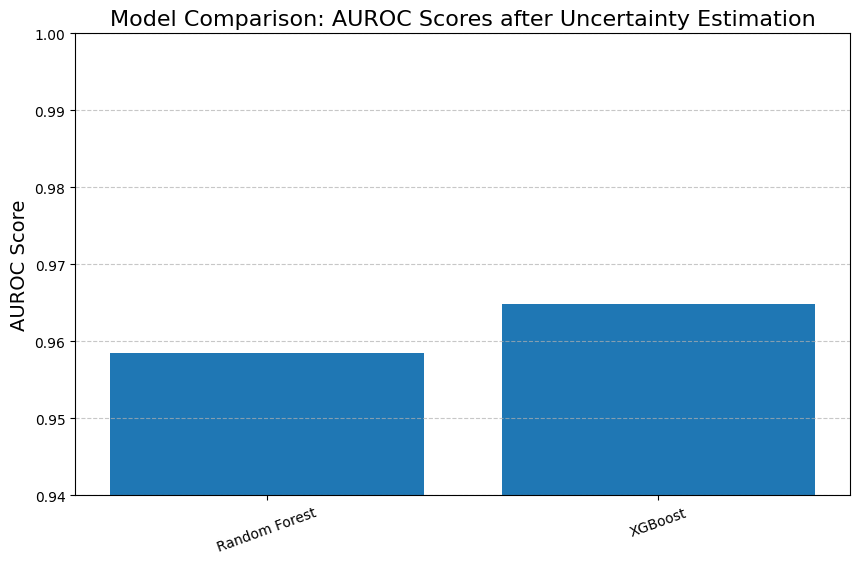

In [6]:
import matplotlib.pyplot as plt

# Models and their AUROC scores
models = ['Random Forest', 'XGBoost']
auroc_scores = [0.9585, 0.9649]  # From the results above

# Plot
plt.figure(figsize=(10,6))
bars = plt.bar(models, auroc_scores)

# Highlight the Deep Ensemble and BNN differently
for bar, model in zip(bars, models):
    if model in ['Deep Ensemble', 'Bayesian NN']:
        bar.set_edgecolor('black')
        bar.set_linewidth(2)

plt.title('Model Comparison: AUROC Scores after Uncertainty Estimation', fontsize=16)
plt.ylabel('AUROC Score', fontsize=14)
plt.ylim(0.94, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=20)
plt.show()
